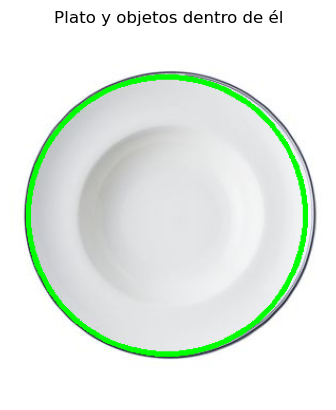

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('plato.jpg')  
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray, (9, 9), 0)

edges = cv2.Canny(blurred, 50, 150)

circles = cv2.HoughCircles(blurred, cv2.HOUGH_GRADIENT, dp=1.2, minDist=100,
                           param1=100, param2=30, minRadius=50, maxRadius=200)

output = img.copy()
mask = np.zeros_like(gray)

if circles is not None:
    circles = np.uint16(np.around(circles))
    for circle in circles[0, :1]: 
        x, y, r = circle
        cv2.circle(output, (x, y), r, (0, 255, 0), 4)
        cv2.circle(mask, (x, y), r, 255, -1)

masked = cv2.bitwise_and(gray, gray, mask=mask)
contornos, _ = cv2.findContours(masked, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

for c in contornos:
    area = cv2.contourArea(c)
    if 300 < area < 10000:  
        x, y, w, h = cv2.boundingRect(c)
        cv2.rectangle(output, (x, y), (x + w, y + h), (255, 0, 0), 2)

plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title('Plato y objetos dentro de él')
plt.axis('off')
plt.show()


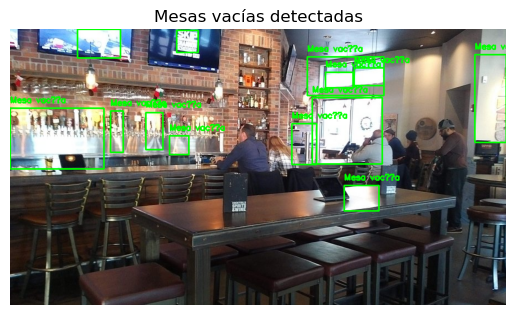

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
img = cv2.imread('image.png')
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

lower_empty = np.array([0, 0, 200])
upper_empty = np.array([180, 30, 255])

mask = cv2.inRange(hsv, lower_empty, upper_empty)

contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
output = img.copy()

for c in contours:
    area = cv2.contourArea(c)
    if area > 500:  
        x, y, w, h = cv2.boundingRect(c)
        cv2.rectangle(output, (x, y), (x + w, y + h), (0, 255, 0), 2)
        cv2.putText(output, 'Mesa vacía', (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 2)

plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title('Mesas vacías detectadas')
plt.axis('off')
plt.show()
